<a href="https://colab.research.google.com/github/Tauhid-Topu-007/Unet/blob/main/UNET2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [2]:
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [3]:
!kaggle datasets download veeralakrishna/butterfly-dataset

Dataset URL: https://www.kaggle.com/datasets/veeralakrishna/butterfly-dataset
License(s): Community Data License Agreement - Permissive - Version 1.0
butterfly-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [4]:
!unzip /content/butterfly-dataset.zip -d /content/

Archive:  /content/butterfly-dataset.zip
replace /content/leedsbutterfly/README.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/leedsbutterfly/README.txt  
replace /content/leedsbutterfly/descriptions/001.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/leedsbutterfly/descriptions/001.txt  
  inflating: /content/leedsbutterfly/descriptions/002.txt  
  inflating: /content/leedsbutterfly/descriptions/003.txt  
  inflating: /content/leedsbutterfly/descriptions/004.txt  
  inflating: /content/leedsbutterfly/descriptions/005.txt  
  inflating: /content/leedsbutterfly/descriptions/006.txt  
  inflating: /content/leedsbutterfly/descriptions/007.txt  
  inflating: /content/leedsbutterfly/descriptions/008.txt  
  inflating: /content/leedsbutterfly/descriptions/009.txt  
  inflating: /content/leedsbutterfly/descriptions/010.txt  
  inflating: /content/leedsbutterfly/images/0010001.png  
  inflating: /content/leedsbutterfly/images/0010002.png  
  inflating: /c

In [5]:
import os
import re
import time

# Numerical Computing
import numpy as np

# Computer Vision
import cv2
from PIL import Image

# Visualization
import matplotlib.pyplot as plt

# Machine Learning
import tensorflow as tf
from sklearn.model_selection import train_test_split

# TensorFlow / Keras
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Conv2DTranspose,
    concatenate,
    Dropout
)

from tensorflow.keras.models import Model

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

%matplotlib inline

## Getting basic stats

In [6]:
image_path='/content/leedsbutterfly/images'
mask_path='/content/leedsbutterfly/segmentations'

In [7]:
#list image and masks
images=os.listdir(image_path)
masks=os.listdir(mask_path)

print(f"The data statistics \n images :{len(images)} masks: {len(masks)}")

The data statistics 
 images :832 masks: 832


In [8]:
#function to find the corresponding mask for given images
def get_corresponding_mask(image_name):
  base_name=image_name.split('.')[0]
  mask_name=f"{base_name}_seg0.png"
  return mask_name

In [9]:
#display few sample images
def show_samples(image_list,num_samples=3):
  plt.figure(figsize=(10,10))
  for i in range(num_samples):
    img=Image.open(os.path.join(image_path,image_list[i]))
    mask_name=get_corresponding_mask(image_list[i])
    mask=Image.open(os.path.join(mask_path,mask_name))

    plt.subplot(2,num_samples,i+1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(2,num_samples, num_samples + i+1)
    plt.imshow(mask)
    plt.title("Mask")
    plt.axis("off")
  plt.show()


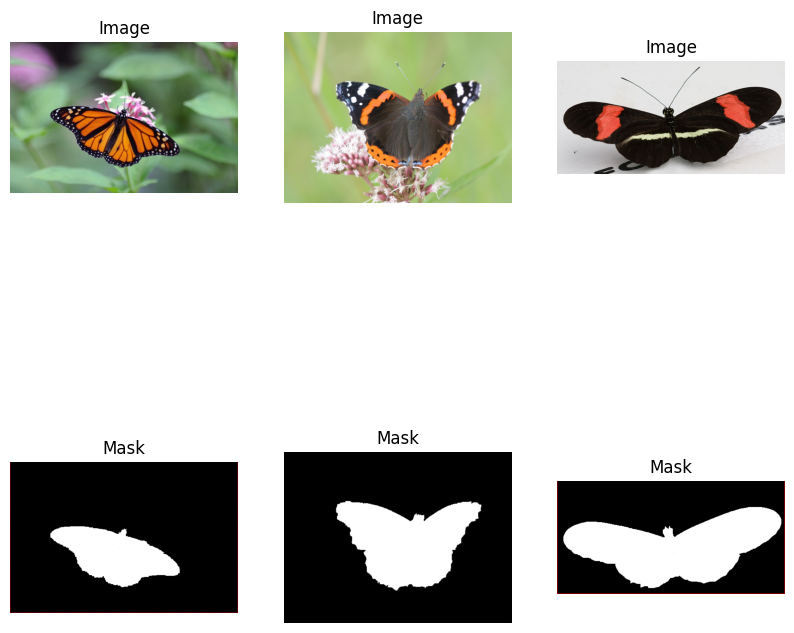

In [10]:
show_samples(images,num_samples=3)

## Load data

In [11]:
def load_data(image_dir, mask_dir, image_shape=256):
    """
    Loads and preprocesses images and masks for training.

    Args:
        image_dir (str): Directory containing the images.
        mask_dir (str): Directory containing the masks.
        image_shape (int, optional): Shape to resize the images and masks. Defaults to 256.

    Returns:
        tuple: Arrays of preprocessed images and masks.
    """
    image_list = []
    mask_list = []

    image_names = os.listdir(image_dir)
    mask_names = [re.sub(r'\.png', '_seg0.png', name) for name in image_names]

    for img_name, mask_name in zip(image_names, mask_names):
        try:
            img = plt.imread(os.path.join(image_dir, img_name))
            mask = plt.imread(os.path.join(mask_dir, mask_name))
        except FileNotFoundError:
            continue

        # Resizing the images and masks
        img_resized = cv2.resize(img, (image_shape, image_shape))
        mask_resized = cv2.resize(mask, (image_shape, image_shape))

        #storing the preprocessed data
        image_list.append(img_resized)
        mask_list.append(mask_resized[:, :,0])

    return np.array(image_list), np.array(mask_list)

In [12]:
#load data
image_dir='/content/leedsbutterfly/images'
mask_dir='/content/leedsbutterfly/segmentations'
images,masks=load_data(image_dir,mask_dir)

In [13]:
images.shape

(832, 256, 256, 3)

## Train test split

In [14]:
X_train,X_val,y_train,y_val=train_test_split(images,masks,test_size=0.2,random_state=42)

In [15]:
print(X_train.shape, X_val.shape, y_train.shape, y_val.shape)

(665, 256, 256, 3) (167, 256, 256, 3) (665, 256, 256) (167, 256, 256)


#Unet architecture

### Building colvolution block

In [16]:
# Function to create a convolutional block for the U-Net model
def convolutional_block(input_tensor, num_filters, kernel_size=3, use_batch_norm=True):
    """
    Performs two convolution operations with optional batch normalization.

    Args:
        input_tensor (tensor): Input to the convolutional block.
        num_filters (int): Number of filters for the convolutional layers.
        kernel_size (int, optional): Size of the convolution kernel. Defaults to 3.
        use_batch_norm (bool, optional): Apply batch normalization if True. Defaults to True.

    Returns:
        tensor: Output after applying convolution, batch normalization, and activation.
    """
    # First convolution
    x = tf.keras.layers.Conv2D(filters=num_filters, kernel_size=(kernel_size, kernel_size),
                               kernel_initializer='he_normal', padding='same')(input_tensor)

    if use_batch_norm:
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)

    # Second convolution
    x = tf.keras.layers.Conv2D(filters=num_filters, kernel_size=(kernel_size, kernel_size),
                               kernel_initializer='he_normal', padding='same')(x)

    if use_batch_norm:
        x = tf.keras.layers.BatchNormalization()(x)
        x = tf.keras.layers.Activation('relu')(x)

    return x

### Building UNET model

In [17]:
# Function to create a U-Net model
def build_unet(input_shape, num_filters=16, dropout_rate=0.1, use_batch_norm=True):
    """
    Builds a U-Net model.
    Args:
        input_shape (tuple): Shape of the input image (height, width, channels).
        num_filters (int, optional): Number of filters for the initial layer. Defaults to 16.
        dropout_rate (float, optional): Dropout rate for regularization. Defaults to 0.1.
        use_batch_norm (bool, optional): Apply batch normalization if True. Defaults to True.
    Returns:
        keras.Model: Compiled U-Net model.
    """
    inputs = tf.keras.layers.Input(input_shape)

    # Encoder path
    c1 = convolutional_block(inputs, num_filters * 1, use_batch_norm=use_batch_norm)
    p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)
    p1 = tf.keras.layers.Dropout(dropout_rate)(p1)

    c2 = convolutional_block(p1, num_filters * 2, use_batch_norm=use_batch_norm)
    p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)
    p2 = tf.keras.layers.Dropout(dropout_rate)(p2)

    c3 = convolutional_block(p2, num_filters * 4, use_batch_norm=use_batch_norm)
    p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)
    p3 = tf.keras.layers.Dropout(dropout_rate)(p3)

    c4 = convolutional_block(p3, num_filters * 8, use_batch_norm=use_batch_norm)
    p4 = tf.keras.layers.MaxPooling2D((2, 2))(c4)
    p4 = tf.keras.layers.Dropout(dropout_rate)(p4)

    # Bottleneck
    c5 = convolutional_block(p4, num_filters * 16, use_batch_norm=use_batch_norm)

    # Decoder path
    u6 = tf.keras.layers.Conv2DTranspose(num_filters * 8, (3, 3), strides=(2, 2), padding='same')(c5)
    u6 = tf.keras.layers.concatenate([u6, c4])  # Changed to lowercase concatenate
    u6 = tf.keras.layers.Dropout(dropout_rate)(u6)
    c6 = convolutional_block(u6, num_filters * 8, use_batch_norm=use_batch_norm)

    u7 = tf.keras.layers.Conv2DTranspose(num_filters * 4, (3, 3), strides=(2, 2), padding='same')(c6)
    u7 = tf.keras.layers.concatenate([u7, c3])  # Changed to lowercase concatenate
    u7 = tf.keras.layers.Dropout(dropout_rate)(u7)
    c7 = convolutional_block(u7, num_filters * 4, use_batch_norm=use_batch_norm)

    u8 = tf.keras.layers.Conv2DTranspose(num_filters * 2, (3, 3), strides=(2, 2), padding='same')(c7)
    u8 = tf.keras.layers.concatenate([u8, c2])  # Changed to lowercase concatenate
    u8 = tf.keras.layers.Dropout(dropout_rate)(u8)
    c8 = convolutional_block(u8, num_filters * 2, use_batch_norm=use_batch_norm)

    u9 = tf.keras.layers.Conv2DTranspose(num_filters * 1, (3, 3), strides=(2, 2), padding='same')(c8)
    u9 = tf.keras.layers.concatenate([u9, c1])  # Changed to lowercase concatenate
    u9 = tf.keras.layers.Dropout(dropout_rate)(u9)
    c9 = convolutional_block(u9, num_filters * 1, use_batch_norm=use_batch_norm)

    # Output layer
    output = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)

    # Model creation
    model = tf.keras.Model(inputs=[inputs], outputs=[output])
    return model

In [18]:
# Instantiate and compile the UNET model
input_shape = (256, 256, 3)
unet_model = build_unet(input_shape, dropout_rate=0.07)
unet_model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

In [19]:
unet_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ max_pooling2d_1[

 Total params: 2,164,593 (8.26 MB)

 Trainable params: 2,161,649 (8.25 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [26]:
#callbacks
early_stopping=EarlyStopping(monitor='val_loss',patience=10,verbose=1,restore_best_weights=True)
reduce_lr=ReduceLROnPlateau(monitor='val_loss',factor=0.1,patience=5,verbose=1,min_lr=1e-6)
model_checkpoint=ModelCheckpoint('unet_model_best.keras', monitor='val_loss',save_best_only=True, verbose=1)

In [27]:
history = unet_model.fit(
    X_train, y_train,
    epochs=100,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[early_stopping,reduce_lr, model_checkpoint]
)


Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6782 - loss: 0.5908   
Epoch 1: val_loss improved from None to 5.37463, saving model to unet_model_best.keras

Epoch 1: finished saving model to unet_model_best.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 117s 3s/step - accuracy: 0.7709 - loss: 0.4975 - val_accuracy: 0.4821 - val_loss: 5.3746 - learning_rate: 0.0010
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 314ms/step - accuracy: 0.8817 - loss: 0.3450
Epoch 2: val_loss did not improve from 5.37463
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 344ms/step - accuracy: 0.8862 - loss: 0.3275 - val_accuracy: 0.4591 - val_loss: 6.3378 - learning_rate: 0.0010
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - accuracy: 0.9014 - loss: 0.2793
Epoch 3: val_loss improved from 5.37463 to 4.23190, saving model to unet_model_best.keras

Epoch 3: finished saving model to unet_model_best.keras
21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 381ms/step - accuracy: 0.9055 - loss: 0.2687 - val_accuracy: 0.5966 - val_loss: 4.2319 - 

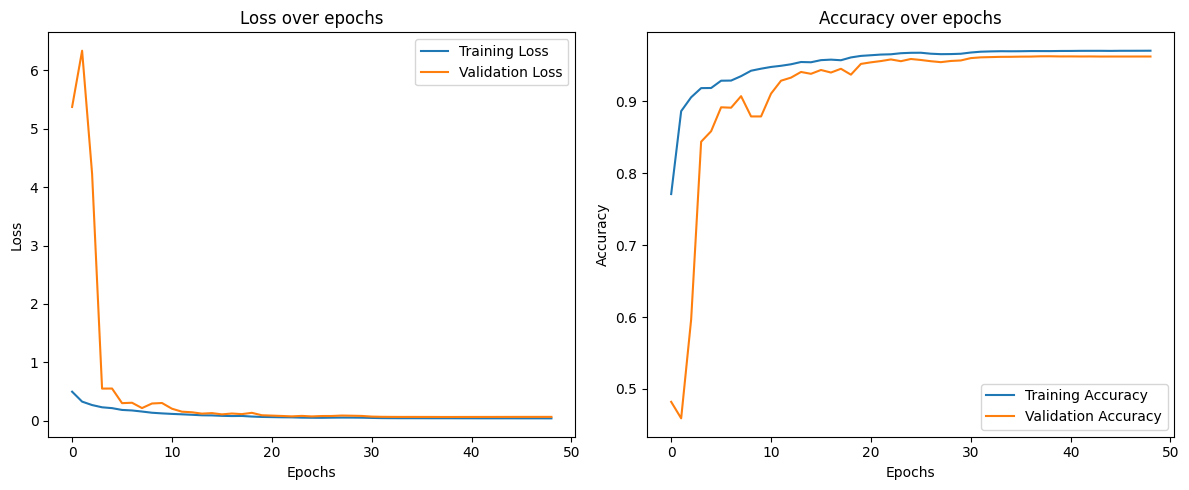

In [28]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [29]:
# Function to predict and time the inference for a single image
def predict_single_image(image, model):
    """
    Predicts the segmentation mask for a single image and times the prediction.

    Args:
        image (array): Input image for prediction.
        model (keras.Model): Trained U-Net model.

    Returns:
        tuple: Predicted mask and inference time.
    """
    start_time = time.time()
    prediction = model.predict(np.expand_dims(image, axis=0))[0, :, :, 0]
    end_time = time.time()
    inference_time = end_time - start_time

    return prediction, inference_time

In [30]:
# Function to visualize the prediction and ground truth
def visualize_segmentation(image, predicted_mask, ground_truth_mask):
    """
    Visualizes the original image, predicted mask, and ground truth mask.
    Args:
        image (array): Original image.
        predicted_mask (array): Predicted mask.
        ground_truth_mask (array): Ground truth mask.
    """
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title('Original Image')
    plt.subplot(1, 3, 2)
    plt.imshow(predicted_mask, cmap='gray')
    plt.title('Predicted Mask')
    plt.subplot(1, 3, 3)
    plt.imshow(ground_truth_mask, cmap='gray')
    plt.title('Ground Truth Mask')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Inference time for a single image: 2.9907 seconds


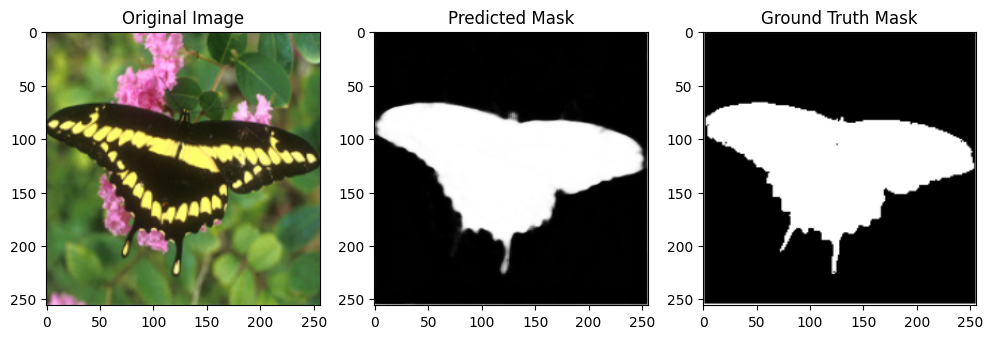

In [31]:
# Example inference on a validation image
sample_image = X_val[0]
sample_ground_truth = y_val[0]

predicted_mask, inference_time = predict_single_image(sample_image, unet_model)
print(f'Inference time for a single image: {inference_time:.4f} seconds')

# Visualize the result
visualize_segmentation(sample_image, predicted_mask, sample_ground_truth)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Inference time for a single image: 0.0859 seconds


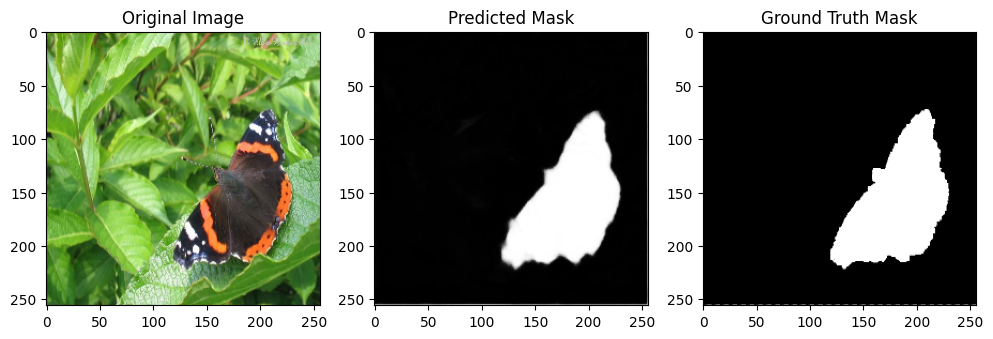

In [32]:
# Example inference on a validation image
sample_image = X_val[10]
sample_ground_truth = y_val[10]

predicted_mask, inference_time = predict_single_image(sample_image, unet_model)
print(f'Inference time for a single image: {inference_time:.4f} seconds')

# Visualize the result
visualize_segmentation(sample_image, predicted_mask, sample_ground_truth)

## Calculating Mean IOU Score

In [33]:
import tensorflow.keras.backend as K

def mean_iou(y_true, y_pred, smooth=1):
    """
    Calculate the mean Intersection over Union (IoU).

    Args:
        y_true (tensor): Ground truth mask.
        y_pred (tensor): Predicted mask.
        smooth (float, optional): Smoothing factor to avoid division by zero. Defaults to 1.

    Returns:
        float: Mean IoU score.
    """
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)



In [35]:
# Get predictions
y_pred = unet_model.predict(X_val)
print(mean_iou(y_val, y_pred))



6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step 
tf.Tensor(0.8692201, shape=(), dtype=float32)


In [36]:
# Get predictions
y_pred = unet_model.predict(X_train)
print(mean_iou(y_train, y_pred))

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 136ms/step
tf.Tensor(0.8997996, shape=(), dtype=float32)


## Adding IOU to the metrics while training model

In [37]:
import tensorflow.keras.backend as K

def dice_coefficient(y_true, y_pred, smooth=1):
    """
    Calculate the Dice coefficient.

    Args:
        y_true (tensor): Ground truth mask.
        y_pred (tensor): Predicted mask.
        smooth (float, optional): Smoothing factor to avoid division by zero. Defaults to 1.

    Returns:
        float: Dice coefficient score.
    """
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def mean_iou(y_true, y_pred, smooth=1):
    """
    Calculate the mean Intersection over Union (IoU).

    Args:
        y_true (tensor): Ground truth mask.
        y_pred (tensor): Predicted mask.
        smooth (float, optional): Smoothing factor to avoid division by zero. Defaults to 1.

    Returns:
        float: Mean IoU score.
    """
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    union = K.sum(y_true_f) + K.sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)

In [38]:
input_shape = (256, 256, 3)
unet_model = build_unet(input_shape, dropout_rate=0.07)

In [39]:
# Compile the U-Net model with Dice coefficient and mean IoU as metrics
unet_model.compile(optimizer='Adam', loss='binary_crossentropy',
    metrics=['accuracy', dice_coefficient, mean_iou])

In [40]:
# Train the model with the additional metrics
history = unet_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, verbose=1)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.6684 - dice_coefficient: 0.4521 - loss: 0.6722 - mean_iou: 0.2923 - val_accuracy: 0.2992 - val_dice_coefficient: 0.4170 - val_loss: 10.4223 - val_mean_iou: 0.2638
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 339ms/step - accuracy: 0.8447 - dice_coefficient: 0.5090 - loss: 0.4949 - mean_iou: 0.3418 - val_accuracy: 0.4539 - val_dice_coefficient: 0.4514 - val_loss: 5.8846 - val_mean_iou: 0.2919
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 350ms/step - accuracy: 0.8791 - dice_coefficient: 0.5669 - loss: 0.4111 - mean_iou: 0.3958 - val_accuracy: 0.5676 - val_dice_coefficient: 0.4719 - val_loss: 4.7768 - val_mean_iou: 0.3093
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 354ms/step - accuracy: 0.8969 - dice_coefficient: 0.6003 - loss: 0.3612 - mean_iou: 0.4293 - val_accuracy: 0.7360 - val_dice_coefficient: 0.5547 - val_loss: 2.2142 - val_mean_iou: 0.3843
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 349ms/step - accuracy: 0.9087 - dice_coefficient

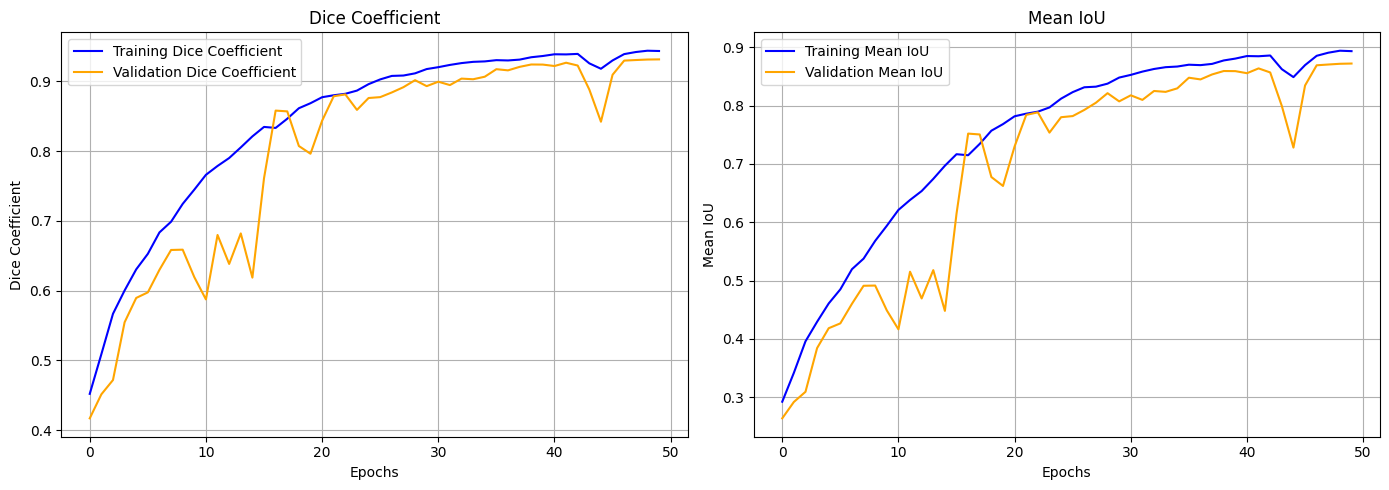

In [48]:
# Plot Dice coefficient and mean IoU during training and validation
plt.figure(figsize=(14, 5))

# Subplot 1: Dice Coefficient
plt.subplot(1, 2, 1)
plt.plot(history.history['dice_coefficient'], label='Training Dice Coefficient', color='blue')
plt.plot(history.history['val_dice_coefficient'], label='Validation Dice Coefficient', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Dice Coefficient')
plt.legend()
plt.grid()
plt.title('Dice Coefficient')

# Subplot 2: Mean IoU
plt.subplot(1, 2, 2)
plt.plot(history.history['mean_iou'], label='Training Mean IoU', color='blue')
plt.plot(history.history['val_mean_iou'], label='Validation Mean IoU', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Mean IoU')
plt.legend()
plt.grid()
plt.title('Mean IoU')

plt.tight_layout()  # Adjust spacing between subplots
plt.show()

In [42]:
def visualize_segmentation_with_cropping(image, predicted_mask, ground_truth_mask):
    """
    Visualizes the original image, predicted mask, ground truth mask, and segmented image.

    Args:
        image (array): Original image.
        predicted_mask (array): Predicted mask.
        ground_truth_mask (array): Ground truth mask.
    """
    # Threshold the predicted mask to create a binary mask for segmentation
    binary_mask = (predicted_mask > 0.5).astype(np.uint8)

    # Plotting the original image, predicted mask, ground truth mask, and segmented image
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(image)
    plt.title('Original Image')

    plt.subplot(1, 4, 2)
    plt.imshow(predicted_mask, cmap='gray')
    plt.title('Predicted Mask')

    plt.subplot(1, 4, 3)
    plt.imshow(ground_truth_mask, cmap='gray')
    plt.title('Ground Truth Mask')

    # Apply the binary mask to the original image to create the segmented output
    segmented_image = cv2.merge((binary_mask, binary_mask, binary_mask)) * image

    plt.subplot(1, 4, 4)
    plt.imshow(segmented_image)
    plt.title('Segmented Image')

    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


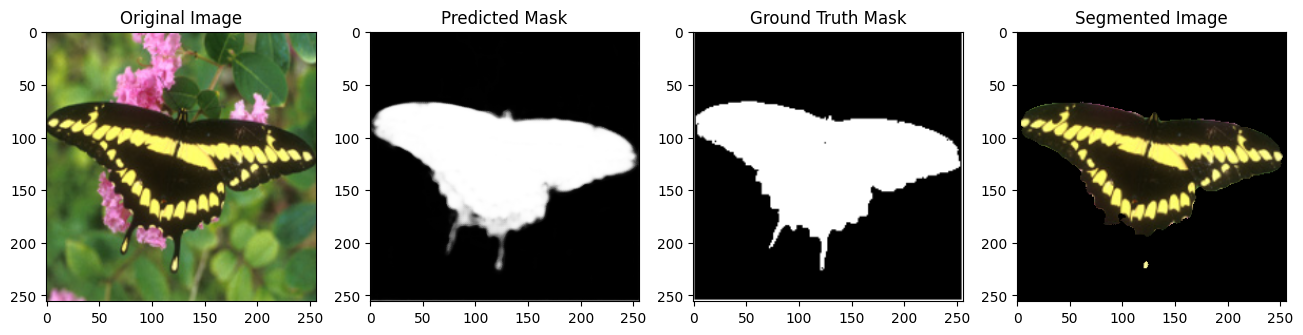

In [43]:
# Example usage
sample_image = X_val[0]
sample_ground_truth = y_val[0]

predicted_mask, _ = predict_single_image(sample_image, unet_model)

# Visualize the segmentation results with cropping
visualize_segmentation_with_cropping(sample_image, predicted_mask, sample_ground_truth)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


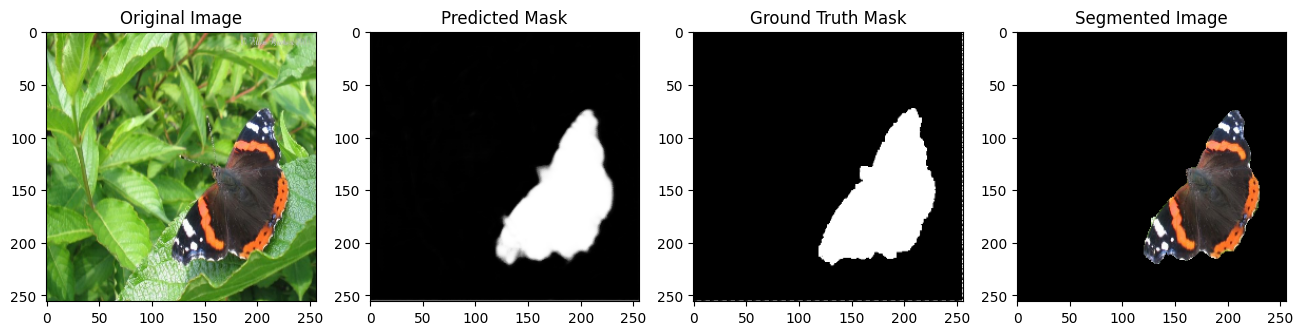

In [44]:
# Example usage
sample_image = X_val[10]
sample_ground_truth = y_val[10]

predicted_mask, _ = predict_single_image(sample_image, unet_model)

# Visualize the segmentation results with cropping
visualize_segmentation_with_cropping(sample_image, predicted_mask, sample_ground_truth)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


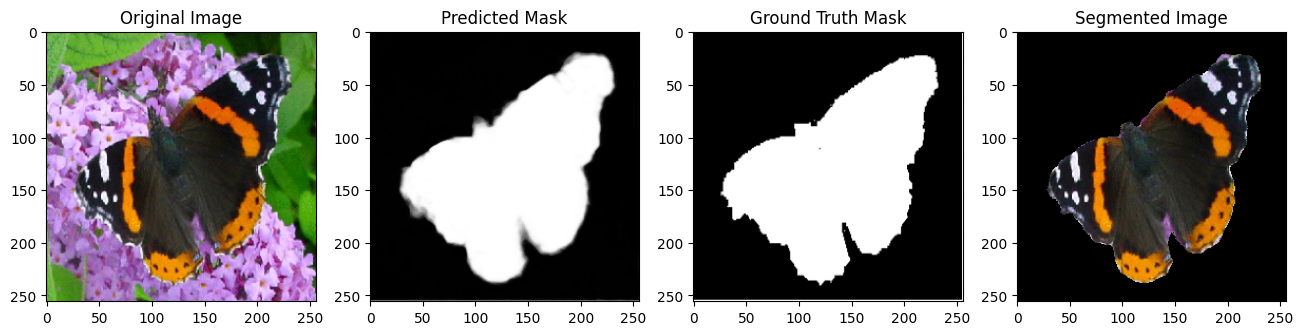

In [45]:
# Example usage
sample_image = X_val[20]
sample_ground_truth = y_val[20]

predicted_mask, _ = predict_single_image(sample_image, unet_model)

# Visualize the segmentation results with cropping
visualize_segmentation_with_cropping(sample_image, predicted_mask, sample_ground_truth)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


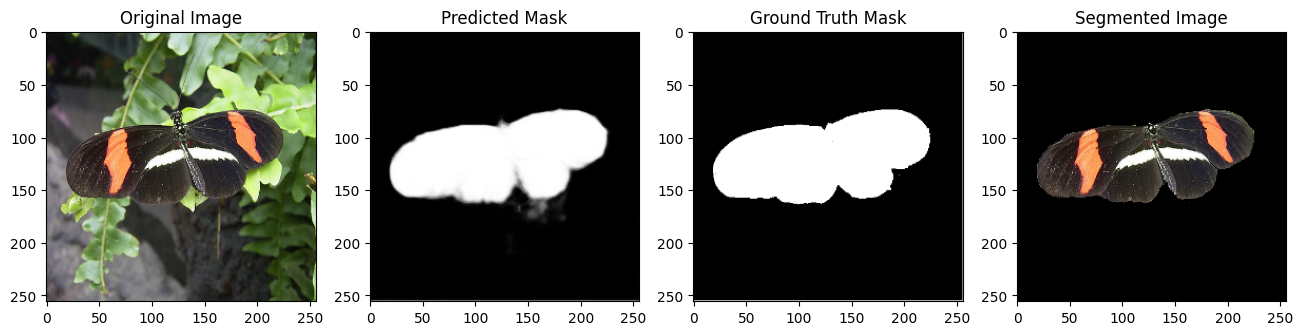

In [47]:
# Example usage
sample_image = X_val[160]
sample_ground_truth = y_val[160]

predicted_mask, _ = predict_single_image(sample_image, unet_model)

# Visualize the segmentation results with cropping
visualize_segmentation_with_cropping(sample_image, predicted_mask, sample_ground_truth)


In [49]:
unet_model.save('final_UNET_Butterfly_Segmentation.keras')